# LSTM-Based Vessel Trajectory Prediction with Local Coordinate Increments

This notebook demonstrates an increment-based trajectory prediction workflow for AIS data. Instead of directly predicting future latitude and longitude values, the model predicts future displacements relative to the last observed input point. The target is represented in a local coordinate system using northward and eastward increments measured in meters.

The workflow includes three main steps:

1. Construct sliding-window samples from AIS trajectories.
2. Train an LSTM model to predict future local-coordinate increments.
3. Convert the predicted increments back to geographic coordinates and visualize one prediction case.


## 1. Training an Increment-Based LSTM Model

This section prepares sequential AIS samples, converts the future trajectory into local-coordinate increments, normalizes both inputs and targets, and trains an LSTM model. The validation metrics are average displacement error (ADE) and final displacement error (FDE), both measured in meters.


In [1]:
import sys, os, numpy as np, pandas as pd
for _m in [k for k in list(sys.modules) if k.startswith('torch._dynamo')]:
    del sys.modules[_m]                 # Clear partially initialized torch dynamo modules.
import torch, torch._dynamo            # Import torch dynamo early to avoid lazy-loading conflicts.
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ---------------- Configuration ----------------
IN_LEN, OUT_LEN = 12, 6
FEATS = ['Lat', 'Lng', 'COG', 'SOG']
BATCH, EPOCHS, LR, HID, LAYERS = 256, 300, 1e-3, 128, 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
R = 6371000.0
os.makedirs('LSTM_delta', exist_ok=True)
torch.manual_seed(0); np.random.seed(0)

df = pd.read_csv('../data/AIS_resampled_5min.csv')   # In the same notebook, this can be changed to: df = res.copy()
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# ---------------- Sliding-window construction ----------------
# The target is defined as future position increments relative to the last input point.
# The local-coordinate target is measured in meters: [delta north, delta east].
def build_windows(d):
    X, Y = [], []
    for _, g in d.groupby('traj_id'):
        a = g.sort_values('Date/Time')[FEATS].values.astype('float32')
        for i in range(len(a) - IN_LEN - OUT_LEN + 1):
            inp = a[i:i+IN_LEN]
            fut = a[i+IN_LEN:i+IN_LEN+OUT_LEN, :2]                          # Future latitude and longitude points.
            lat0, lng0 = inp[-1, 0], inp[-1, 1]                            # Local origin: the last input point.
            dn = np.radians(fut[:, 0] - lat0) * R                          # Northward displacement in meters.
            de = np.radians(fut[:, 1] - lng0) * R * np.cos(np.radians(lat0))  # Eastward displacement in meters.
            X.append(inp)
            Y.append(np.stack([dn, de], axis=1))                           # Shape: (OUT_LEN, 2), [delta north, delta east].
    return np.asarray(X, 'float32'), np.asarray(Y, 'float32')

ids = df['traj_id'].unique().copy(); np.random.shuffle(ids)
cut = int(0.8 * len(ids))
tr_ids, va_ids = set(ids[:cut]), set(ids[cut:])
Xtr, Ytr = build_windows(df[df.traj_id.isin(tr_ids)])
Xva, Yva = build_windows(df[df.traj_id.isin(va_ids)])

# ---------------- Normalization ----------------
# The input features are normalized by training-set statistics.
# The target increments are also z-score normalized because their units are meters.
mu = Xtr.reshape(-1, len(FEATS)).mean(0); sd = Xtr.reshape(-1, len(FEATS)).std(0) + 1e-6
y_mu = Ytr.reshape(-1, 2).mean(0); y_sd = Ytr.reshape(-1, 2).std(0) + 1e-6
Xtr, Xva = (Xtr - mu) / sd, (Xva - mu) / sd
Ytr, Yva = (Ytr - y_mu) / y_sd, (Yva - y_mu) / y_sd

def loader(X, Y, shuffle):
    ds = TensorDataset(torch.tensor(X), torch.tensor(Y))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)
tr_dl, va_dl = loader(Xtr, Ytr, True), loader(Xva, Yva, False)

# ---------------- LSTM model ----------------
# The network predicts future local-coordinate increments instead of absolute coordinates.
class LSTMNet(nn.Module):
    def __init__(self, in_dim=len(FEATS), hid=HID, layers=LAYERS, out_len=OUT_LEN):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hid, layers, batch_first=True)
        self.fc   = nn.Linear(hid, out_len * 2)
        self.out_len = out_len
    def forward(self, x):
        _, (h, _) = self.lstm(x)          # h: (layers, B, hid)
        return self.fc(h[-1]).view(-1, self.out_len, 2)

# ---------------- Evaluation metrics ----------------
# ADE and FDE are computed in meters after inverse normalization.
@torch.no_grad()
def evaluate(model, dl):
    model.eval(); P, G, loss = [], [], 0.0
    for xb, yb in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = model(xb)
        loss += nn.functional.mse_loss(out, yb).item() * len(xb)
        P.append(out.cpu().numpy()); G.append(yb.cpu().numpy())
    pred = np.concatenate(P) * y_sd + y_mu      # Convert normalized outputs back to meters.
    gt   = np.concatenate(G) * y_sd + y_mu
    d = np.sqrt(((pred - gt) ** 2).sum(-1))     # Point-wise displacement error, shape: (N, OUT_LEN).
    return loss/len(dl.dataset), d.mean(), d[:, -1].mean()

# ---------------- Training ----------------
model = LSTMNet().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
best_ade, history = float('inf'), []

for ep in range(1, EPOCHS + 1):
    model.train(); tot = 0.0
    for xb, yb in tr_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        l = nn.functional.mse_loss(model(xb), yb)
        l.backward(); opt.step()
        tot += l.item() * len(xb)
    tr_loss = tot / len(tr_dl.dataset)
    va_loss, ade, fde = evaluate(model, va_dl)
    history.append({'epoch': ep, 'train_loss': tr_loss, 'val_loss': va_loss,
                    'val_ADE_m': ade, 'val_FDE_m': fde})
    if ade < best_ade:
        best_ade = ade
        torch.save({'model': model.state_dict(), 'mu': mu, 'sd': sd,
                    'y_mu': y_mu, 'y_sd': y_sd,
                    'cfg': {'in_dim': len(FEATS), 'hid': HID,
                            'layers': LAYERS, 'out_len': OUT_LEN}},
                   'LSTM_delta/best_model.pth')
    if ep % 50 == 0 or ep == 1:
        print(f'Epoch {ep:4d} | train {tr_loss:.5f} | val {va_loss:.5f} '
              f'| ADE {ade:7.1f} m | FDE {fde:7.1f} m')

pd.DataFrame(history).to_csv('LSTM_delta/metrics.csv', index=False)
print(f'\nBest val ADE = {best_ade:.1f} m  ->  LSTM_delta/best_model.pth  |  saved LSTM_delta/metrics.csv')


Epoch    1 | train 0.24091 | val 0.04300 | ADE  1181.3 m | FDE  1990.1 m


KeyboardInterrupt: 

## 2. Visualizing One Prediction Example

This section loads the best saved model, selects one trajectory window, predicts future local-coordinate increments, converts them back to latitude and longitude, and compares the predicted trajectory with the ground truth on a map.


traj_id=71  ADE=815.7 m  FDE=1324.9 m


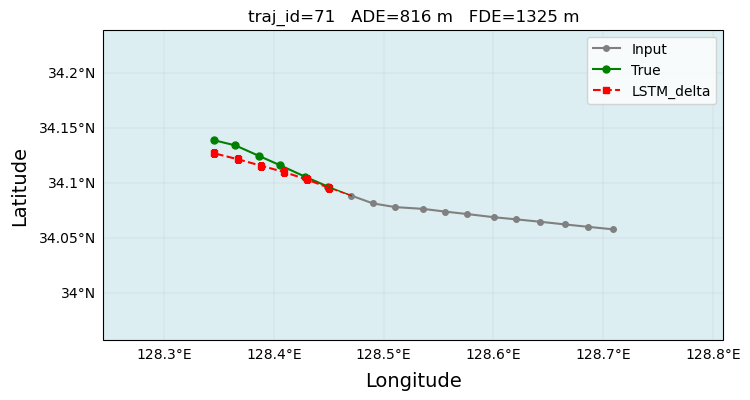

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

IN_LEN, OUT_LEN, FEATS = 12, 6, ['Lat', 'Lng', 'COG', 'SOG']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
R = 6371000.0
SEED = 7; np.random.seed(SEED)

# --- Model definition: must be consistent with the training cell. ---
class LSTMNet(nn.Module):
    def __init__(self, in_dim, hid, layers, out_len):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hid, layers, batch_first=True)
        self.fc   = nn.Linear(hid, out_len * 2); self.out_len = out_len
    def forward(self, x):
        _, (h, _) = self.lstm(x); return self.fc(h[-1]).view(-1, self.out_len, 2)

# --- Load the best model and the normalization statistics. ---
ckpt = torch.load('LSTM_delta/best_model.pth', map_location=DEVICE, weights_only=False)
mu, sd, cfg = ckpt['mu'], ckpt['sd'], ckpt['cfg']
y_mu, y_sd = ckpt['y_mu'], ckpt['y_sd']
model = LSTMNet(**cfg).to(DEVICE); model.load_state_dict(ckpt['model']); model.eval()

# --- Select one trajectory window for visual inspection. ---
df = pd.read_csv('AIS_resampled_5min.csv')      # In the same notebook, this can be changed to: df = res.copy()
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
tid = 71
g = df[df.traj_id == tid].sort_values('Date/Time')[FEATS].values.astype('float32')
s = np.random.randint(0, len(g) - IN_LEN - OUT_LEN + 1)
inp  = g[s:s+IN_LEN]                              # Input sequence.
true = g[s+IN_LEN:s+IN_LEN+OUT_LEN, :2]          # Ground-truth future points.
lat0, lng0 = inp[-1, 0], inp[-1, 1]              # Local origin: the last input point.

# --- Prediction: normalized meter increments -> meter increments -> latitude/longitude. ---
x = torch.tensor((inp - mu) / sd).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    delta = model(x).cpu().numpy()[0] * y_sd + y_mu      # [delta north, delta east] in meters.
pred = np.empty_like(true)
pred[:, 0] = lat0 + np.degrees(delta[:, 0] / R)
pred[:, 1] = lng0 + np.degrees(delta[:, 1] / (R * np.cos(np.radians(lat0))))

# --- Compute ADE and FDE for this sample. ---
def hav(a, b):
    la1, lo1 = np.radians(a[:,0]), np.radians(a[:,1])
    la2, lo2 = np.radians(b[:,0]), np.radians(b[:,1])
    h = np.sin((la2-la1)/2)**2 + np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
    return 2*R*np.arcsin(np.sqrt(h))
d = hav(pred, true)
print(f'traj_id={tid}  ADE={d.mean():.1f} m  FDE={d[-1]:.1f} m')

# --- Plot the input trajectory, ground truth, and predicted future trajectory. ---
inp_ll = inp[:, :2]
lats = np.concatenate([inp_ll[:,0], true[:,0], pred[:,0]])
lngs = np.concatenate([inp_ll[:,1], true[:,1], pred[:,1]])
pad = max((lats.max()-lats.min()), (lngs.max()-lngs.min())) * 0.25 + 0.01

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lngs.min()-pad, lngs.max()+pad, lats.min()-pad, lats.max()+pad])
ax.add_feature(cfeature.LAND, facecolor='#eeeee4')
ax.add_feature(cfeature.OCEAN, facecolor='#dceef2')
ax.add_feature(cfeature.COASTLINE, lw=0.6)
gl = ax.gridlines(draw_labels=True, lw=0.3, alpha=0.5)
gl.top_labels = gl.right_labels = False

tf = ccrs.PlateCarree()
ax.plot(inp_ll[:,1], inp_ll[:,0], '-o', c='gray',  ms=4, transform=tf, label='Input')
ax.plot(true[:,1],  true[:,0],   '-o', c='green', ms=5, transform=tf, label='True')
ax.plot(pred[:,1],  pred[:,0],   '--s', c='red',  ms=5, transform=tf, label='LSTM_delta')
ax.plot([inp_ll[-1,1], true[0,1]], [inp_ll[-1,0], true[0,0]], c='green', lw=1, transform=tf)
ax.plot([inp_ll[-1,1], pred[0,1]], [inp_ll[-1,0], pred[0,0]], '--', c='red', lw=1, transform=tf)
ax.text(0.5, -0.10, 'Longitude', va='top', ha='center',
        transform=ax.transAxes, fontsize=14)
ax.text(-0.12, 0.5, 'Latitude', va='center', ha='right',
        rotation='vertical', transform=ax.transAxes, fontsize=14)
ax.legend(loc='best')
ax.set_title(f'traj_id={tid}   ADE={d.mean():.0f} m   FDE={d[-1]:.0f} m')

plt.savefig('traj30_lstm_delta.png', dpi=900, bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()
